In [ ]:
!pip install qiskit qiskit-aer pylatexenc -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFTGate
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector, state_fidelity


# =====================================================================
# STEP 1: CLASSICAL BENCHMARK
# =====================================================================
print("--- Step 1: Classical Diagonalization ---")

X = np.array([[0, 1], [1, 0]])
Y = np.array([[0, -1j], [1j, 0]])
Z = np.array([[1, 0], [0, -1]])

H_matrix = np.kron(X, X) + np.kron(Y, Y) + np.kron(Z, Z)

eigenvalues, eigenvectors = eigh(H_matrix)

print("Classical Eigenvalues:")
print(eigenvalues)
print()


# =====================================================================
# STEP 2: CONTROLLED TIME EVOLUTION
# =====================================================================
def apply_controlled_trotter_step(qc, control, target_reg, time_param):
    """
    Applies controlled U(t) = exp(-iHt),
    where H = XX + YY + ZZ.
    """

    t0, t1 = target_reg[0], target_reg[1]

    # Controlled ZZ
    qc.cx(t0, t1)
    qc.crz(2 * time_param, control, t1)
    qc.cx(t0, t1)

    # Controlled XX
    qc.h(t0)
    qc.h(t1)
    qc.cx(t0, t1)
    qc.crz(2 * time_param, control, t1)
    qc.cx(t0, t1)
    qc.h(t0)
    qc.h(t1)

    # Controlled YY
    qc.rx(np.pi / 2, t0)
    qc.rx(np.pi / 2, t1)
    qc.cx(t0, t1)
    qc.crz(2 * time_param, control, t1)
    qc.cx(t0, t1)
    qc.rx(-np.pi / 2, t0)
    qc.rx(-np.pi / 2, t1)


# =====================================================================
# STEP 3: STATE PREPARATION
# =====================================================================
def prepare_state(qc, q_target, state_name):
    """
    Prepares one of the four eigenstates of the two-site Heisenberg model.
    """

    if state_name == "singlet":
        # (|01> - |10>) / sqrt(2)
        qc.x(q_target[0])
        qc.h(q_target[0])
        qc.cx(q_target[0], q_target[1])
        qc.x(q_target[1])

    elif state_name == "triplet_plus":
        # (|01> + |10>) / sqrt(2)
        qc.h(q_target[0])
        qc.cx(q_target[0], q_target[1])
        qc.x(q_target[1])

    elif state_name == "triplet_00":
        # |00>
        pass

    elif state_name == "triplet_11":
        # |11>
        qc.x(q_target[0])
        qc.x(q_target[1])

    else:
        raise ValueError("Unknown state name")


def exact_statevector(state_name):
    """
    Returns the exact 2-qubit eigenstate vector.
    Basis order: |00>, |01>, |10>, |11>.
    """

    if state_name == "singlet":
        return Statevector([0, 1 / np.sqrt(2), -1 / np.sqrt(2), 0])

    elif state_name == "triplet_plus":
        return Statevector([0, 1 / np.sqrt(2), 1 / np.sqrt(2), 0])

    elif state_name == "triplet_00":
        return Statevector([1, 0, 0, 0])

    elif state_name == "triplet_11":
        return Statevector([0, 0, 0, 1])

    else:
        raise ValueError("Unknown state name")


# =====================================================================
# STEP 4: RUN QPE FOR ONE STATE
# =====================================================================
def run_qpe_for_state(state_name, theoretical_energy):
    num_counting = 4
    evolution_time = 0.5
    shots = 2048

    q_count = QuantumRegister(num_counting, "count")
    q_target = QuantumRegister(2, "target")
    c_out = ClassicalRegister(num_counting, "output")

    qc = QuantumCircuit(q_count, q_target, c_out)

    # Prepare target eigenstate
    prepare_state(qc, q_target, state_name)

    # Check fidelity of the prepared eigenstate before QPE
    prep_qc = QuantumCircuit(2)
    prepare_state(prep_qc, prep_qc.qubits, state_name)

    simulated_state = Statevector.from_instruction(prep_qc)
    exact_state = exact_statevector(state_name)
    fidelity = state_fidelity(simulated_state, exact_state)

    # Put counting qubits in superposition
    for q in range(num_counting):
        qc.h(q_count[q])

    # Controlled U^(2^q)
    for q in range(num_counting):
        repetitions = 2 ** q
        for _ in range(repetitions):
            apply_controlled_trotter_step(
                qc,
                q_count[q],
                q_target,
                evolution_time
            )

    # Inverse QFT
    qc.append(QFTGate(num_counting).inverse(), q_count)

    # Measure counting register
    qc.measure(q_count, c_out)

    # Run simulator
    simulator = AerSimulator()
    compiled_circuit = transpile(qc, simulator)
    result = simulator.run(compiled_circuit, shots=shots).result()
    counts = result.get_counts()

    # Decode highest probability bitstring
    highest_measured_string = max(counts, key=counts.get)
    decimal_value = int(highest_measured_string, 2)

    theta = decimal_value / (2 ** num_counting)

    # Phase wrap-around
    if theta >= 0.5:
        theta -= 1.0

    measured_energy = -(2 * np.pi * theta) / evolution_time
    error = abs(measured_energy - theoretical_energy)

    return {
        "state_name": state_name,
        "bitstring": highest_measured_string,
        "theta": theta,
        "measured_energy": measured_energy,
        "theoretical_energy": theoretical_energy,
        "error": error,
        "fidelity": fidelity,
        "counts": counts,
        "circuit": qc
    }


# =====================================================================
# STEP 5: RUN ALL FOUR STATES
# =====================================================================
states_to_test = [
    ("singlet", -3),
    ("triplet_plus", 1),
    ("triplet_00", 1),
    ("triplet_11", 1)
]

all_results = []

for state_name, theory_energy in states_to_test:
    result = run_qpe_for_state(state_name, theory_energy)
    all_results.append(result)


# =====================================================================
# STEP 6: PRINT FINAL ENERGY TABLE
# =====================================================================
print("================ FINAL ENERGY TABLE ================")
print(
    f"{'State':<15} "
    f"{'Bitstring':<10} "
    f"{'Theta':<10} "
    f"{'QPE Energy':<15} "
    f"{'Theory':<10} "
    f"{'Error':<10}"
)
print("-" * 80)

for r in all_results:
    print(
        f"{r['state_name']:<15} "
        f"{r['bitstring']:<10} "
        f"{r['theta']:<10.4f} "
        f"{r['measured_energy']:<15.4f} "
        f"{r['theoretical_energy']:<10.4f} "
        f"{r['error']:<10.4f}"
    )


print()
print("================ STATE FIDELITY TABLE ================")
print(f"{'State':<15} {'Fidelity':<15}")
print("-" * 35)

for r in all_results:
    print(f"{r['state_name']:<15} {r['fidelity']:<15.8f}")


# =====================================================================
# STEP 7: SAVE HISTOGRAMS FOR EACH STATE
# =====================================================================
for r in all_results:
    fig = plot_histogram(r["counts"])
    fig.savefig(f"histogram_{r['state_name']}.png")
    plt.close()


# =====================================================================
# STEP 8: SAVE ONE CIRCUIT IMAGE
# =====================================================================
all_results[0]["circuit"].draw(
    output="mpl",
    filename="qpe_heisenberg_circuit.png"
)


print("\nSaved files:")
print("qpe_heisenberg_circuit.png")
print("histogram_singlet.png")
print("histogram_triplet_plus.png")
print("histogram_triplet_00.png")
print("histogram_triplet_11.png")

--- Step 1: Classical Diagonalization ---
Classical Eigenvalues:
[-3.  1.  1.  1.]

================ FINAL ENERGY TABLE ================
State           Bitstring  Theta      QPE Energy      Theory     Error     
--------------------------------------------------------------------------------
singlet         0100       0.2500     -3.1416         -3.0000    0.1416    
triplet_plus    1111       -0.0625    0.7854          1.0000     0.2146    
triplet_00      1111       -0.0625    0.7854          1.0000     0.2146    
triplet_11      1111       -0.0625    0.7854          1.0000     0.2146    

================ STATE FIDELITY TABLE ================
State           Fidelity       
-----------------------------------
singlet         1.00000000     
triplet_plus    1.00000000     
triplet_00      1.00000000     
triplet_11      1.00000000     

Saved files:
qpe_heisenberg_circuit.png
histogram_singlet.png
histogram_triplet_plus.png
histogram_triplet_00.png
histogram_triplet_11.png


================ SCALING TABLE ================
n    Depth     Gate Count  CNOT Count  Bitstring   Energy      Error     
-------------------------------------------------------------------------------------
4    158       202         61          0100        -3.1416     0.1416    
5    320       401         125         01000       -3.1416     0.1416    
6    642       793         253         001111      -2.9452     0.0548    
8    2566      3116        1021        00111101    -2.9943     0.0057    


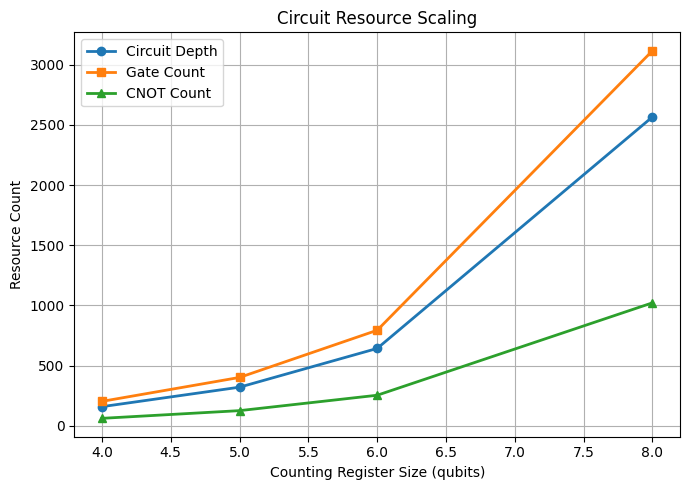

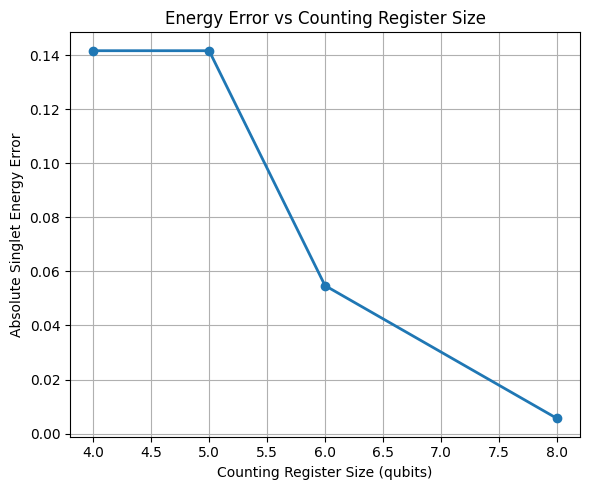

Saved: resource_scaling.png and error_scaling.png


In [ ]:
#SCALING EXPERIMENT
def run_singlet_scaling(num_counting):
    evolution_time = 0.5
    shots = 2048
    theoretical_energy = -3

    q_count = QuantumRegister(num_counting, "count")
    q_target = QuantumRegister(2, "target")
    c_out = ClassicalRegister(num_counting, "output")

    qc = QuantumCircuit(q_count, q_target, c_out)

    prepare_state(qc, q_target, "singlet")

    for q in range(num_counting):
        qc.h(q_count[q])

    for q in range(num_counting):
        for _ in range(2 ** q):
            apply_controlled_trotter_step(qc, q_count[q], q_target, evolution_time)

    qc.append(QFTGate(num_counting).inverse(), q_count)
    qc.measure(q_count, c_out)

    simulator = AerSimulator()
    compiled = transpile(qc, simulator)

    result = simulator.run(compiled, shots=shots).result()
    counts = result.get_counts()

    bitstring = max(counts, key=counts.get)
    k = int(bitstring, 2)

    theta = k / (2 ** num_counting)
    theta_wrapped = theta - 1 if theta >= 0.5 else theta

    measured_energy = -(2 * np.pi * theta_wrapped) / evolution_time
    error = abs(measured_energy - theoretical_energy)

    ops = compiled.count_ops()
    cnot_count = ops.get("cx", 0)

    return {
        "n": num_counting,
        "depth": compiled.depth(),
        "gate_count": compiled.size(),
        "cnot_count": cnot_count,
        "bitstring": bitstring,
        "theta": theta,
        "measured_energy": measured_energy,
        "error": error
    }


scaling_results = []

for n in [4, 5, 6, 8]:
    scaling_results.append(run_singlet_scaling(n))


print("================ SCALING TABLE ================")
print(f"{'n':<5}{'Depth':<10}{'Gate Count':<12}{'CNOT Count':<12}{'Bitstring':<12}{'Energy':<12}{'Error':<10}")
print("-" * 85)

for r in scaling_results:
    print(
        f"{r['n']:<5}"
        f"{r['depth']:<10}"
        f"{r['gate_count']:<12}"
        f"{r['cnot_count']:<12}"
        f"{r['bitstring']:<12}"
        f"{r['measured_energy']:<12.4f}"
        f"{r['error']:<10.4f}"
    )


# Figure 3: Resource scaling
n_values = [r["n"] for r in scaling_results]
depth_values = [r["depth"] for r in scaling_results]
gate_values = [r["gate_count"] for r in scaling_results]
cnot_values = [r["cnot_count"] for r in scaling_results]
error_values = [r["error"] for r in scaling_results]

plt.figure(figsize=(7, 5))
plt.plot(n_values, depth_values, marker="o", linewidth=2, label="Circuit Depth")
plt.plot(n_values, gate_values, marker="s", linewidth=2, label="Gate Count")
plt.plot(n_values, cnot_values, marker="^", linewidth=2, label="CNOT Count")
plt.xlabel("Counting Register Size (qubits)")
plt.ylabel("Resource Count")
plt.title("Circuit Resource Scaling")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("resource_scaling.png", dpi=300)
plt.show()


# Figure 4: Error scaling
plt.figure(figsize=(6, 5))
plt.plot(n_values, error_values, marker="o", linewidth=2)
plt.xlabel("Counting Register Size (qubits)")
plt.ylabel("Absolute Singlet Energy Error")
plt.title("Energy Error vs Counting Register Size")
plt.grid(True)
plt.tight_layout()
plt.savefig("error_scaling.png", dpi=300)
plt.show()

print("Saved: resource_scaling.png and error_scaling.png")